# Graph ALMM

In [63]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

Temporarily trying to add error related plots feature

## GRSU

In [64]:
# Graph plotter

def graph_plotter(i, A_error, RMSE_plot, A_error_array, RMSE_array, title_0):
    x_iterations = [j for j in range(i)]

    plots_to_show = []
    if A_error:
        plots_to_show.append(("A Error (||A_new - A||)", A_error_array))
    if RMSE_plot:
        plots_to_show.append(("RMSE vs Ground Truth", RMSE_array))

    if plots_to_show:
        fig, axes = plt.subplots(1, len(plots_to_show), figsize=(6*len(plots_to_show), 5))
        if len(plots_to_show) == 1:
            axes = [axes]  # make it indexable even with just one subplot

        for ax, (title, data) in zip(axes, plots_to_show):
            ax.plot(x_iterations, data)
            ax.set_xlabel("Iterations")
            ax.set_ylabel(title)
            ax.set_title(title)

        fig.suptitle(title_0, fontsize=16)
        plt.tight_layout()
        plt.show()

    return
    

In [65]:
def algo_3_grsu_error(X, X_hat, A_hat, alpha, lam, gamma, rho, A_gt, max_iters=1000, eps=1e-3, k=50, A_error = False, RMSE_plot = False, title_0 = ""):
    """
    Executes the Graph-Regularized Semi-Supervised Unmixing (GRSU) model (Algorithm 3).

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    X_hat (numpy.ndarray): Labeled data matrix (p, M).
    A_hat (numpy.ndarray): Labeled abundance matrix / pseudo-labels (q, M).
    alpha (float): Weighting parameter for end-member estimation.
    lam (float): Graph regularization parameter (lambda).
    gamma (float): ADMM penalty parameter for S-T constraint.
    rho (float): ADMM penalty parameter for A-B constraint.
    max_iters (int): Maximum number of ADMM iterations.
    eps (float): Error tolerance for convergence.
    k (int): Number of nearest neighbors for graph construction.

    Returns:
    A_GRSU (numpy.ndarray): Final estimated abundance map (q, N).
    S_GRSU (numpy.ndarray): Final estimated end-member spectrum matrix (p, q).
    """
    p, N = X.shape
    q, M = A_hat.shape
    A_error_array = []
    RMSE_array = []


    # --- 1. Graph Construction & Laplacian Partitioning ---
    X_tilde = np.concatenate((X_hat, X), axis=1)
    G, W = build_custom_knn_graph(X_tilde.T, K=k)

    labeled_indices = np.arange(M)
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    # --- 2. Initialization via GLU (Algorithm 2) ---
    A, S = algo_2_glu(X, X_hat, A_hat, alpha, k=k)

    # Initialize ADMM auxiliary and dual variables
    B = np.copy(A)
    B_bar = np.zeros((q, N))
    T_bar = np.zeros((p, q))

    # Pre-compute constants that do not change during iterations
    I_q = np.eye(q)
    I_N_sparse = sps.eye(N, format='csr')

    # Terms in T's update
    X_hat_A_hat_T_alpha2 = (alpha**2) * (X_hat @ A_hat.T)
    A_hat_A_hat_T_alpha2 = (alpha**2) * (A_hat @ A_hat.T)

    # Terms in B's update
    L_B_system = L_uu + (rho / lam) * I_N_sparse
    L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

    Err = 1.0
    i = 0

    # --- 3. ADMM Iteration Loop ---
    while i < max_iters and Err > eps:

        # a) T subproblem update
        term1_T = (X @ A.T) + X_hat_A_hat_T_alpha2 + gamma * (S + T_bar)
        term2_T = (A @ A.T) + A_hat_A_hat_T_alpha2 + gamma * I_q
        T = term1_T @ np.linalg.inv(term2_T)

        # b) S subproblem update
        S_new = np.maximum(T - T_bar, 0)

        # c) A subproblem update
        term1_A = np.linalg.inv((S_new.T @ S_new) + rho * I_q)
        term2_A = (S_new.T @ X) + rho * (B - B_bar)
        A_unproj = term1_A @ term2_A
        A_new = project_onto_simplex(A_unproj)

        # d) B subproblem update (Graph Regularized Laplace Learning)
        # We solve the transposed system: L_B_system * B^T = RHS_B
        RHS_B = -L_lu_T_A_hat_T + (rho / lam) * (A_new.T + B_bar.T)
        B_new_T = np.zeros((N, q))

        for j in range(q):
            B_new_T[:, j], _ = spla.cg(L_B_system, RHS_B[:, j])
        B_new = B_new_T.T

        # e) Update dual variables
        B_bar_new = B_bar + (A_new - B_new)
        T_bar_new = T_bar + (S_new - T)

        # f) Calculate convergence error
        # Protect against division by zero in the denominator
        norm_S = np.linalg.norm(S, 'fro')
        norm_A = np.linalg.norm(A, 'fro')

        err_S = np.linalg.norm(S_new - S, 'fro') / norm_S if norm_S > 0 else 0
        err_A = np.linalg.norm(A_new - A, 'fro') / norm_A if norm_A > 0 else 0

        Err = max(err_S, err_A)

        # g) Advance state for next iteration
        
        # Calculate error
        if A_error:
            A_error_array.append(np.linalg.norm(A_new - A))
        if RMSE_plot:
            RMSE_array.append(RMSE(A, A_gt))

        S = S_new
        A = A_new
        B = B_new
        B_bar = B_bar_new
        T_bar = T_bar_new

        i += 1

    # Plot
    graph_plotter(i, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)


    return A, S

In [66]:
def run_unmixing_pipeline_example_grsu(X, A_gt, S_gt, N, iters, alpha = 10.0, lam = 1.0, gamma = 1.0, rho = 1.0, m_0 = 2, print_bool = True, OH_labels = True, GRSU_bool = True, A_error = False, RMSE_plot = False, title_0 = ""):
    # ==========================================
    # Phase 0: Load Data (Mocking Jasper Ridge)
    # ==========================================
    #print("Loading data...")
    #N = 10000  # Number of pixels (e.g., 100x100 image)
    #p = 198    # Number of spectral bands [cite: 286]
    #q = 4      # Number of latent end-members (Tree, Water, Dirt, Road) [cite: 287, 288]

    # Mock full hyperspectral image X: shape (p, N)
    #X = np.random.rand(p, N, seed=42)

    # Mock ground-truth abundance map (only used to simulate human labeling)
    #A_gt = np.random.dirichlet(np.ones(q), size=N, seed=42).T

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================
    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=int(0.004*N), num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322]
    A_hat_exact = A_gt[:, labeled_indices]
    A_hat_OH = generate_one_hot_labels(A_hat_exact)

    # Pick between Exact or OH labels
    if OH_labels:
        A_hat_test = A_hat_OH
        label_title = "OH"
    else:
        A_hat_test = A_hat_exact
        label_title = "Exact"

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool and GRSU_bool:
        print(f"Running GRSU (and GLU) Unmixing on {label_title}...")
    elif print_bool:
         print(f"Running GLU Unmixing on {label_title}...")

    # Hyperparameters based on the Jasper Ridge dataset in Table II [cite: 339, 340]
    # alpha = 10.0
    # lam = 1.0
    # gamma = 1.0
    # rho = 1.0

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    # If we are only running GLU
    if not GRSU_bool:
        A_final, S_final = algo_2_glu(X, X_hat, A_hat_test, alpha, k=int(N*0.005))
    else:
        A_final, S_final = algo_3_grsu_error(
            X=X,
            X_hat=X_hat,
            A_hat=A_hat_test,
            alpha=alpha,
            lam=lam,
            gamma=gamma,
            rho=rho,
            max_iters=iters,
            A_gt = A_gt,
            eps=1e-3,
            k=int(N*0.005),
            A_error = A_error,
            RMSE_plot = RMSE_plot,
            title_0 = title_0
        )

    # Calculate RMSE and SAD
    A_rmse = RMSE(A_final, A_gt)
    S_sad = SAD(S_final, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_final.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_final, A_rmse, S_sad

## ALMM

In [127]:
def algo_2_almm_optimized_error(X, S, A_gt, alpha, beta, gamma, eta, maxIter, A_error = False, RMSE_plot = False, title_0 = ""):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    A_initial = SCLSU(X, S)
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)
    A_error_array = []
    RMSE_array = []

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_initial)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    random_matrix = np.random.randn(p, L)
    E, _ = np.linalg.qr(random_matrix)

    # Initialize scalars
    t = 0
    xi = 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = (xi * G) + Lambda + (xi * H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new = term1_A * diag_inv
        A_new = A_new / (A_new.sum(axis=0, keepdims=True) + 1e-10)

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E_new) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # G, H, U subproblems
        term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        term2_G = np.sign(A_new - (Lambda / xi))
        G_new = term1_G * term2_G 
        H_new = np.maximum(0, A_new - (Upsilon / xi))
        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter(t, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)
    
    return E, A, T_final, B

## Graph ALMM

In [81]:
def algo_2_graph_almm_optimized_error(X, A_0, S, alpha, beta, gamma, eta, maxIter, xi_0, L_uu, L_lu_T_A_hat_T, labeled_indices, A_error, RMSE_plot, A_gt, title_0):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)
    A_error_array = []
    RMSE_array = []

    #A_0 = SCLSU(X, S)
    #print("Number of labeled points:", len(labeled_indices))

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_0)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    # random_matrix = np.random.randn(p, L)
    # E, _ = np.linalg.qr(random_matrix)

    # E = S - vca(X)
    Ae, _, _ = vca(X, R = q)
    diff = S - Ae


    # Pad with random columns to reach L total, then orthogonalize via QR
    pad = np.random.randn(p, L - diff.shape[1])
    E_init_raw = np.hstack([diff, pad])   # shape (p, L)

    E, _ = np.linalg.qr(E_init_raw)       # (p, L), orthonormal columns, but "seeded" by your real diff


    # Initialize scalars
    t = 0
    xi = xi_0 # originally 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    # Derive unlabeled indices from labeled_indices (test)
    all_indices = np.arange(N)
    unlabeled_indices = np.setdiff1d(all_indices, labeled_indices)
    N_unlabeled = len(unlabeled_indices)  # should match L_uu.shape[0]

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = ((xi* 1) * G) + Lambda + ((xi *2)* H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new_unproj = term1_A * diag_inv
        A_new_unproj = A_new_unproj / (A_new_unproj.sum(axis=0, keepdims=True) + 1e-10)
        A_new = project_onto_simplex(A_new_unproj) # Project onto the simplex for nonnegativity

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # # E subproblem (Right-side solve using Transpose)
        # term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        # term2_E_inv = (B_new @ B_new.T) + xi * I_L
        # E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # # Q subproblem
        # term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        # term2_Q = (eta * Q) + (xi * E_new) - Pi
        # Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q_new) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # G, H, U subproblems
        # term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        # term2_G = np.sign(A_new - (Lambda / xi))
        # G_new = term1_G * term2_G 

        Z_0 = A_new - (Lambda / xi)
        G_new = half_threshold(Z_0, alpha, xi)

        # Replacing G update with B

        # # Terms in B's update (replaced rho / lam with xi for now)
        # I_N_sparse = sps.eye(N, format='csr')
        # L_B_system = L_uu + (xi) * I_N_sparse
        # #L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

        # RHS_G = -L_lu_T_A_hat_T + (xi) * A_new.T + Lambda.T
        # G_new_T = np.zeros((N, q))

        # for j in range(q):
        #     G_new_T[:, j], _ = spla.cg(L_B_system, RHS_G[:, j])
        # G_new = G_new_T.T


        # H subproblem — solve only on unlabeled portion
        I_N_unlabeled_sparse = sps.eye(N_unlabeled, format='csr')
        L_B_system = L_uu + xi * I_N_unlabeled_sparse

        # Only take unlabeled columns of A_new and Lambda for the RHS
        A_new_unlabeled = A_new[:, unlabeled_indices]      # shape (q, N_unlabeled)
        Lambda_unlabeled = Lambda[:, unlabeled_indices]     # shape (q, N_unlabeled)

        RHS_G = -L_lu_T_A_hat_T + xi * A_new_unlabeled.T + Lambda_unlabeled.T  # (N_unlabeled, q)
        H_unlabeled_T = np.zeros((N_unlabeled, q))

        for j in range(q):
            H_unlabeled_T[:, j], _ = spla.cg(L_B_system, RHS_G[:, j])

        
        H_unlabeled = H_unlabeled_T.T  # (q, N_unlabeled)

        # Reassemble full-size H: labeled portion anchored to A_new, unlabeled portion from graph solve
        H_new = np.zeros((q, N))
        H_new[:, labeled_indices] = A_new[:, labeled_indices]
        H_new[:, unlabeled_indices] = H_unlabeled
        
        #H_new = np.maximum(0, A_new - (Upsilon / xi)) (temporarily disable)

        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))
        

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter(t, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)
    
    return E, A, T_final, B

In [69]:
def run_unmixing_pipeline_example_graph_almm(X, A_gt, S_gt, N, alpha, beta, gamma, eta, maxIter, M_total_0, m_0 = 2, xi_0 = 1e-3, OH_labels = True, print_bool = True, A_error = False, RMSE_plot = False, title_0 = ""):

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================

    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    #  M_total_0 = int(0.004*N) is the default
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=M_total_0, num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322] or exact labels
    A_hat_exact = A_gt[:, labeled_indices]
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    if OH_labels:
        A_hat_OH = generate_one_hot_labels(A_hat_exact)
        L_lu_T_A_hat_T = L_lu.T @ A_hat_OH.T
        label_title = "OH"
    else:
        L_lu_T_A_hat_T = L_lu.T @ A_hat_exact.T
        label_title = "Exact"

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool:
        print(f"Running ALMM (and GLU) Unmixing on {label_title}...")

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    if OH_labels:
        A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_OH, alpha, k=int(N*0.005))
    else:
        A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_exact, alpha, k=int(N*0.005))

    # The second condition number is a lot worse than the first
    # print("Condition number of S_gt_chem.T @ S_gt_chem:", np.linalg.cond(S_gt_chem.T @ S_gt_chem))
    # print("Condition number of S_GLU.T @ S_GLU:", np.linalg.cond(S_GLU.T @ S_GLU))

    E_final, A_final, T_final, B_final = algo_2_graph_almm_optimized_error(
        X, A_GLU, S_GLU, alpha = alpha, 
        beta = beta, gamma = gamma, eta = eta, 
        maxIter = maxIter, xi_0 = xi_0, 
        L_uu = L_uu, L_lu_T_A_hat_T = L_lu_T_A_hat_T, labeled_indices = labeled_indices,
        A_error = A_error, RMSE_plot = RMSE_plot, A_gt = A_gt, title_0 = title_0)

    # Calculate RMSE and SAD

    # Check for labeling issues
    corr = np.corrcoef(A_final[0], A_gt[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_final
    else:
        A_f_corrected = A_final

    A_rmse = RMSE(A_f_corrected, A_gt)
    S_sad = SAD(S_GLU, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_GLU.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_GLU, A_rmse, S_sad

# Chemical Data

In [128]:
data_chem = np.load('synth_CuSO4_data.npy', allow_pickle = True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data_chem.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (Chemistry Sample):", data_chem['X'].shape)
print("Shape of A_gt (Abundance Map):", data_chem['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data_chem['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst chemical's concentration in X (how much of class 1?):\n", data_chem['X'][0, 0])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 1.1565849036959073


In [129]:
# Grabbing X, S, and A from the file
A_gt_chem= data_chem['A_gt']
S_gt_chem = data_chem['S_gt']
X_chem = data_chem['X']

# Checking the shapes
print(type(S_gt_chem))
print(S_gt_chem.shape)
print(S_gt_chem.dtype)

print(type(A_gt_chem))
print(A_gt_chem.shape)
print(A_gt_chem.dtype)

print("Shape of X:", X_chem.shape)

<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)


In [130]:
# Subsample for faster parameter testing
N_full = X_chem.shape[1]  # total number of samples
N_sub = 500  # or whatever smaller size you want to test with

np.random.seed(42)
idx = np.random.choice(N_full, N_sub, replace=False)

X_chem_sub = X_chem[:, idx]
A_gt_chem_sub = A_gt_chem[:, idx]

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...


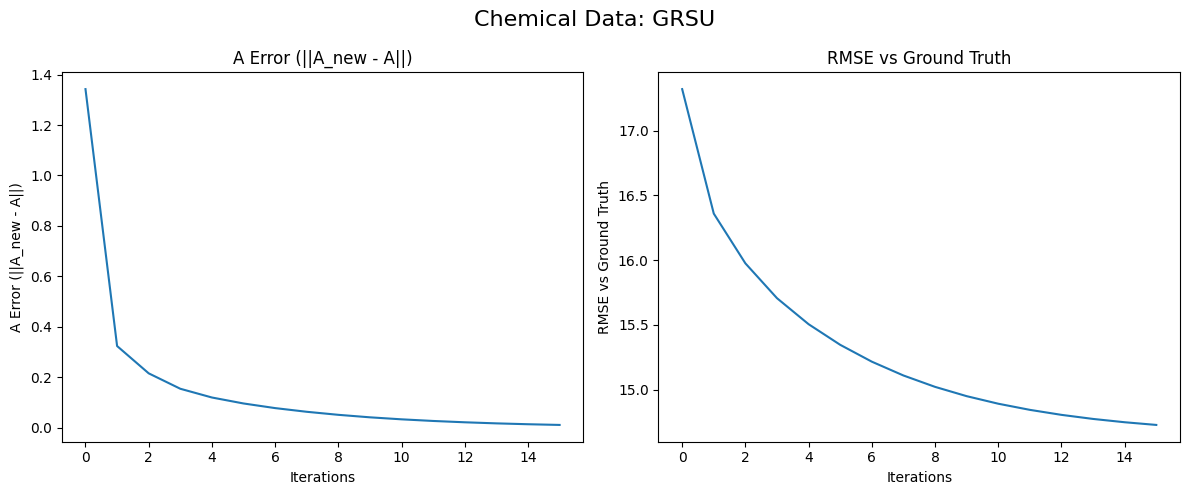

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 14.710649471862888
Final Endmember SAD: 23.453336702298987


In [131]:
# GRSU
iters = 50
samples = 1000
# Parameters from previous testing
alpha_0 = 0.055
lam_0 = 1000
gamma_0 = 100.0
rho_0 = 100.0

# Run on best parameters
A_f_chem_GRSU, S_f_chem_GRSU, A_rmse_chem_GRSU, S_sad_chem_GRSU = run_unmixing_pipeline_example_grsu(X_chem, A_gt_chem, S_gt_chem, N = samples, iters = iters,
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, OH_labels = False, GRSU_bool = True, A_error = True, RMSE_plot = True, 
                                                        title_0 = "Chemical Data: GRSU")

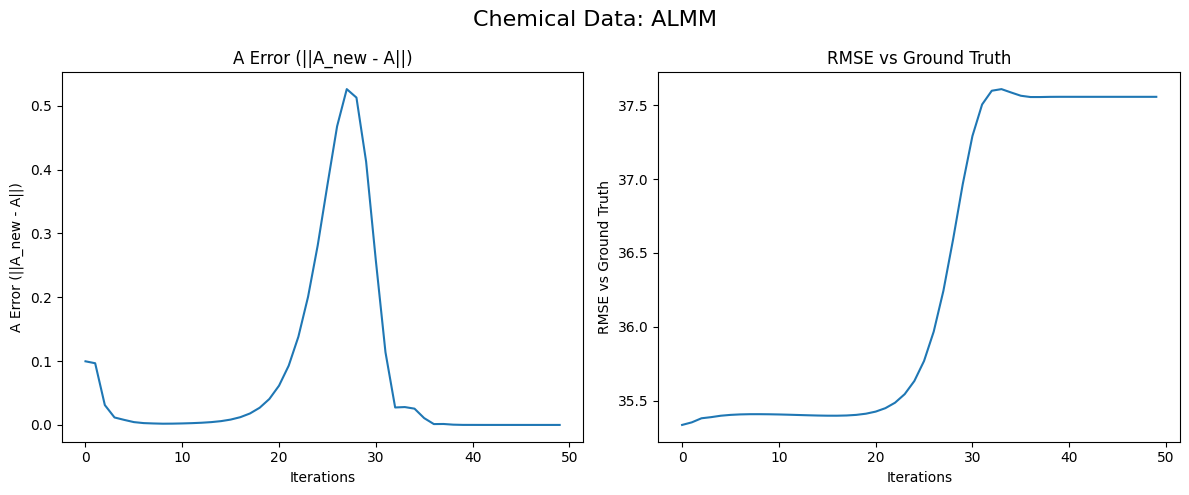

In [132]:
# ALMM
alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2

# Pick the best alpha
best_rmse = np.inf
best_alpha = 1e-6
E_f_chem_ALMM, A_f_chem_ALMM, T_f_chem_ALMM, B_f_chem_ALMM = algo_2_almm_optimized_error(X_chem, S_gt_chem, A_gt = A_gt_chem, 
                                                                                   alpha = best_alpha, beta = beta, gamma = gamma, eta = eta, maxIter = iters,
                                                                                   A_error = True, RMSE_plot = True,
                                                                                   title_0 = "Chemical Data: ALMM")

In [133]:
# ALMM-GLU

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 20 # changed from 50
samples = 500

# Pick the best alpha
#run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, a, beta, gamma, eta, maxIter = iters, M_total_0 = int(0.004*2*samples), m_0 = 2, print_bool = False)
best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_chem_sub, A_gt_chem_sub, S_gt_chem, 
                                                                                     samples, a, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*5*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = True, print_bool = False, A_error = False, RMSE_plot = False,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with OH labels, default samples, xi = 1e-1)")


    print(f"alpha={a:.6f} -> RMSE={A_rmse:.4f}, SAD={S_sad:.4f}")

    if A_rmse < best_rmse:
        best_rmse = A_rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}, SAD: {S_sad}")

alpha=0.005500 -> RMSE=14.6966, SAD=38.0734
alpha=0.000550 -> RMSE=14.1367, SAD=32.1895
alpha=0.000055 -> RMSE=16.0199, SAD=29.7882
alpha=0.000005 -> RMSE=15.0477, SAD=31.8090
alpha=0.000001 -> RMSE=16.6774, SAD=27.8784

Best alpha: 0.0005499999999999999, RMSE: 14.1367, SAD: 27.87842442145632


Test: A with OH labels, default samples, xi = 1e-1
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


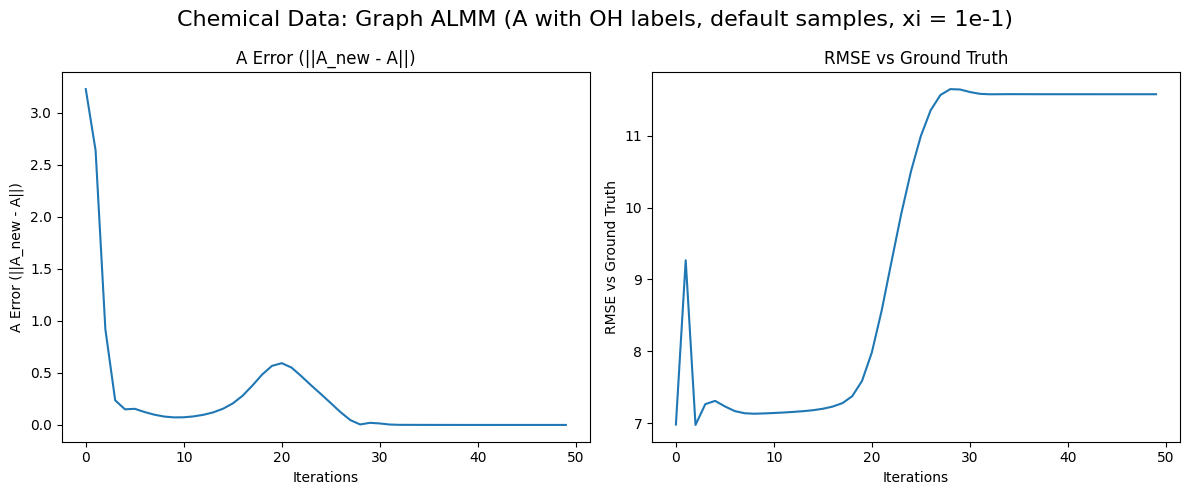

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 11.579618153298872
Final Endmember SAD: 32.00419374212496


In [134]:
# ALMM-GLU

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 50 # changed from 50
samples = 1000

# Pick the best alpha
# best_rmse = np.inf
# best_alpha = 1e-7

# Test: A with OH labels, default samples, xi = 1e-1
# maxIter=10 -> RMSE=9.0805
# maxIter=15 -> RMSE=6.3223
# maxIter=20 -> RMSE=3.4021
# maxIter=25 -> RMSE=3.5662
# maxIter=30 -> RMSE=3.5427
# maxIter=40 -> RMSE=3.5426
# maxIter=50 -> RMSE=3.5426

# RMSE
# 3.5425320610060456 (100 iterations)
# 3.5424986711323525 (150 iterations)

print(f"Test: A with OH labels, default samples, xi = 1e-1")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_chem, A_gt_chem, S_gt_chem, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*4*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = True, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with OH labels, default samples, xi = 1e-1)")



Test: A with Exact labels, default samples, xi = 1e-1
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on Exact...


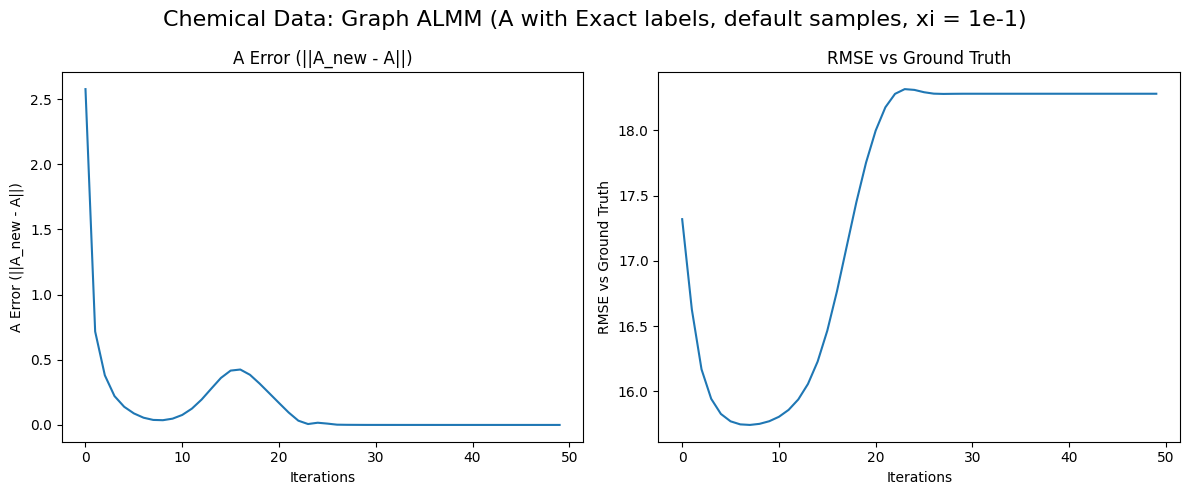

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 18.28079531005721
Final Endmember SAD: 19.357309640619775


In [135]:
print(f"Test: A with Exact labels, default samples, xi = 1e-1")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_chem, A_gt_chem, S_gt_chem, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*samples), m_0 = 2, xi_0 = 1e-1, 
                                                                                     OH_labels = False, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with Exact labels, default samples, xi = 1e-1)")


# Nonlinear Data

In [136]:
# Load data
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

# Grabbing X, S, and A from the file
A_gt_nl = data['A_gt']
S_gt_nl = data['S_gt']
X_nl = data['X']

# Checking the shapes
print(type(S_gt_nl))
print(S_gt_nl.shape)
print(S_gt_nl.dtype)

print(type(A_gt_nl))
print(A_gt_nl.shape)
print(A_gt_nl.dtype)

print("Shape of X:", X_nl.shape)

# Reshaping X from spatial image (10, 1000, 30) to 2D image (30, 10000)
H, W, p = X_nl.shape  # H=10, W=1000, p=30
X_nl_flat = X_nl.reshape(-1, p).T  # reshape to (p, N) = (30, 10000)

print(X_nl_flat.shape)  # should print (30, 2500)

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 250, 30)
Shape of A_gt (Abundance Map): (2, 2500)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.53910909 0.46784716 0.51651596 0.51511246 0.54243879 0.52064358
 0.51943605 0.52593777 0.53434579 0.51118315 0.51952582 0.45491021
 0.48604329 0.50390983 0.47451358 0.48900189 0.55472187 0.53542633
 0.46566486 0.46165341 0.51478674 0.51466119 0.51180038 0.5016153
 0.53460008 0.47453781 0.47549698 0.51345648 0.47629452 0.53555711]
<class 'numpy.ndarray'>
(30, 2)
float64
<class 'numpy.ndarray'>
(2, 2500)
float64
Shape of X: (10, 250, 30)
(30, 2500)


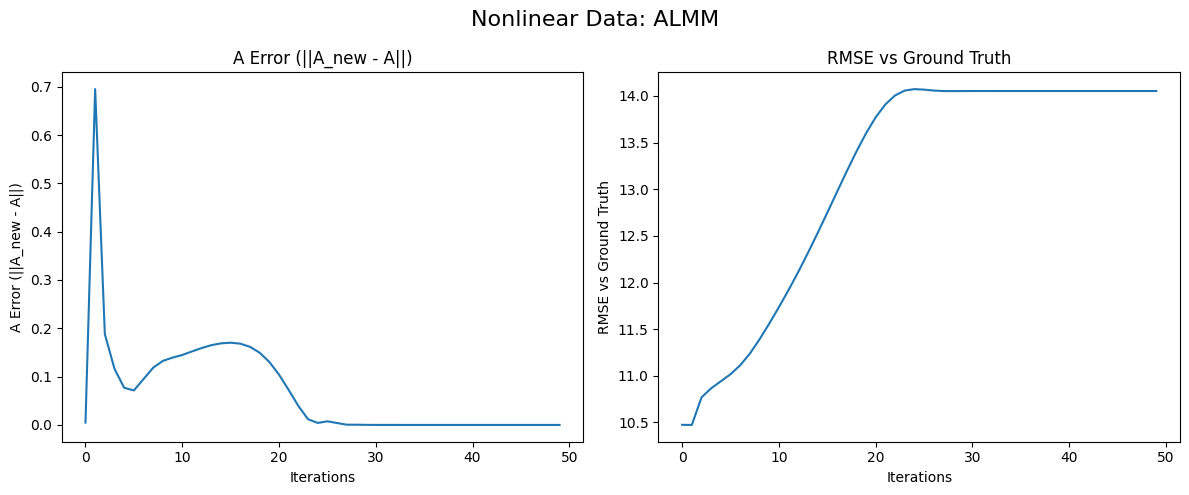

In [137]:
# ALMM
alpha = 2e-5 # I think this was from a previous test
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2

E_f_chem_ALMM, A_f_chem_ALMM, T_f_chem_ALMM, B_f_chem_ALMM = algo_2_almm_optimized_error(X_nl_flat, S_gt_nl, A_gt = A_gt_nl, 
                                                                                   alpha = alpha, beta = beta, gamma = gamma, eta = eta, maxIter = iters,
                                                                                   A_error = True, RMSE_plot = True,
                                                                                   title_0 = "Nonlinear Data: ALMM")

In [138]:
# ALMM-GLU
alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 20 # changed from 50
samples = 2500

best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    A_f_nl_ALMM_GLU, S_f, A_rmse, S_sad = run_unmixing_pipeline_example2(X_nl_flat, A_gt_nl, S_gt_nl, samples, a, beta, gamma, eta, maxIter = iters, M_total_0 = int(0.004*2*samples),  m_0 = 2, xi_0 = 1e-2, OH_labels = False, print_bool = False)

    # Check for labeling issues
    corr = np.corrcoef(A_f_nl_ALMM_GLU[0], A_gt_nl[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f_nl_ALMM_GLU
    else:
        A_f_corrected = A_f_nl_ALMM_GLU

    rmse = RMSE(A_f_corrected, A_gt_nl)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# Best alpha: 5.4999999999999995e-05, RMSE: 0.9883
# Testing: A with exact labels, double samples, xi = 1e-2
# maxIter=10 -> RMSE=0.5594
# maxIter=15 -> RMSE=0.8861
# maxIter=20 -> RMSE=0.9883
# maxIter=25 -> RMSE=0.9724
# maxIter=30 -> RMSE=0.9708
# maxIter=40 -> RMSE=0.9706
# maxIter=50 -> RMSE=0.9706


alpha=0.005500 -> RMSE=7.3371
alpha=0.000550 -> RMSE=1.0398
alpha=0.000055 -> RMSE=0.9883
alpha=0.000005 -> RMSE=0.9983
alpha=0.000001 -> RMSE=0.9993

Best alpha: 5.4999999999999995e-05, RMSE: 0.9883


Test: A with exact labels, double samples, xi = 1e-2
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on Exact...


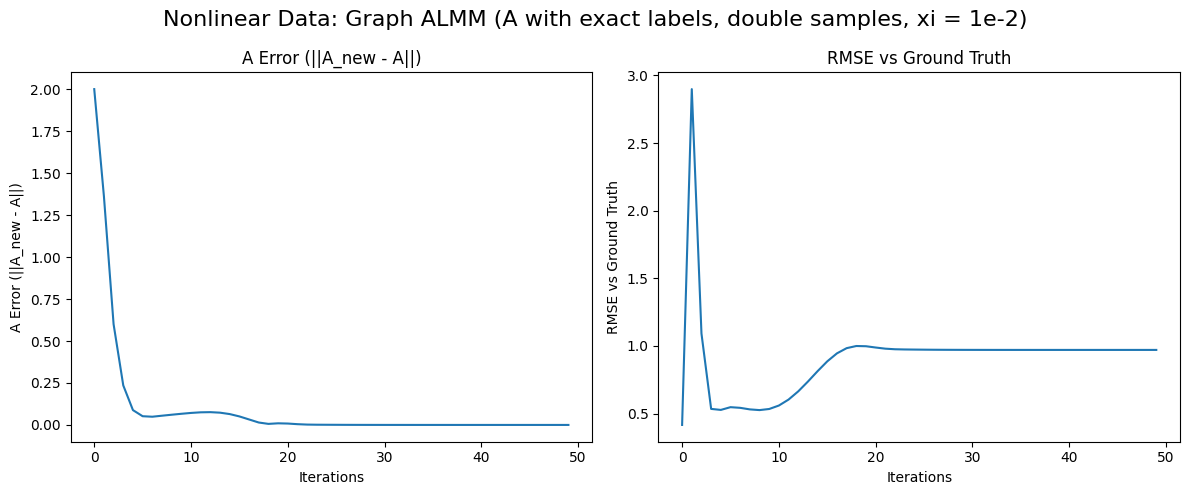

Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 0.9705617464589147
Final Endmember SAD: 18.77325030915321


In [139]:
iters = 50
# 0.9705617464589147
print(f"Test: A with exact labels, double samples, xi = 1e-2")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_nl_flat, A_gt_nl, S_gt_nl, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*2*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = False, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Nonlinear Data: Graph ALMM (A with exact labels, double samples, xi = 1e-2)")


Test: A with OH labels, double samples, xi = 1e-2
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


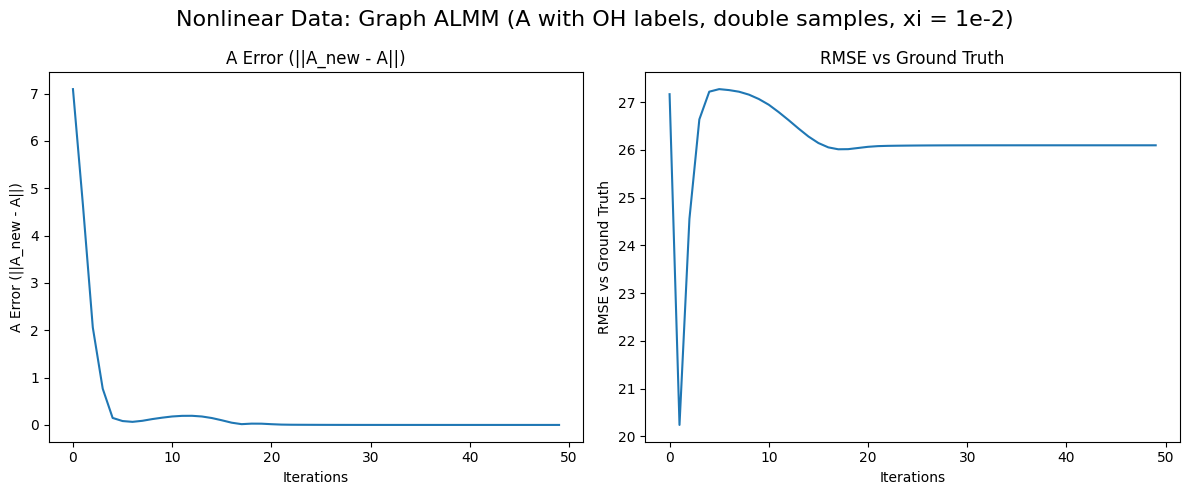

Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 26.096665156355964
Final Endmember SAD: 15.496125371750468


In [140]:
print(f"Test: A with OH labels, double samples, xi = 1e-2")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_nl_flat, A_gt_nl, S_gt_nl, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*2*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = True, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Nonlinear Data: Graph ALMM (A with OH labels, double samples, xi = 1e-2)")
